In [ ]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
dt = ds.Coco("/home/wanderer2414/coco2017/")
# x = dt.getTrainTensor(0)
# ds.ImgWrite("test0.png", ds.TensorToImg(x))

In [ ]:
# import torch
# torch.cuda.empty_cache()

In [ ]:
# import MyRCNN
# from torch import device, load, Tensor
# model = MyRCNN.Model(device=device("cuda"))
# model.model.load_state_dict(load("model.pth"))

In [ ]:
import MyRCNN
from torch import device
model = MyRCNN.Model(device("cuda"))
model.train(dt, MyRCNN.MyBBLoss)

tensor(0.3693, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.0912, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.6318, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4686, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.0863, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.7632, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.5288, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.0937, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.7790, device='cuda:0', grad_fn=<MeanBackward0>)
[00:01:33] 0.8740602731704712                                                                        1        /      100tensor(0.6207, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1060, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.5546, device='cuda:0', grad_fn=<MeanBackward0>)
[00:01:13] 0.749472439289093              █                                                          2        /      100tensor(0.6191, device='cuda:0', grad_fn=<MeanBackward0>) tensor(0.1066, devi

In [ ]:
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)

Trainable parameters: 97930


In [ ]:
from torch import Tensor, where, zeros_like
from torch.nn.functional import pad, unfold
def highest_pool2d(x, kernel_size=3, stride=1, padding=0) -> Tensor:
    if padding > 0:
        x = pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    M = patches.max(dim=2, keepdim=True).values
    patches = patches[:, :, 0:1, :] - M
    patches[patches == 0] = M[patches==0]
    patches[patches < 0] = 0
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return patches.view(B, C, H_out, W_out)

Min -3.726705312728882, Max 4.178606033325195
tensor([[ -28.,   11., 1260.,  647.],
        [ -34.,    9., 1268.,  649.],
        [ -28.,    9., 1260.,  651.],
        [ -36.,    6., 1270.,  654.],
        [ -29.,   19., 1263.,  643.]], device='cuda:0',
       grad_fn=<SqueezeBackward0>)
tensor([359.1700, 146.1700, 471.6200, 359.7400,   4.0000])


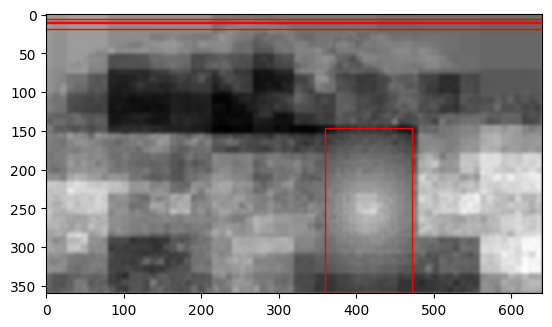

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch import Tensor, arange, float as tfloat, topk, zeros_like,stack
from torch.nn.functional import sigmoid, conv2d, relu, avg_pool2d, interpolate
i = 0
x: Tensor = dt.getTrainTensor(i).to(device=device("cuda"))
H, W = x.shape[-2:]
result = model.model(x)
score = result[0][:, 0:1, :, :]
color = model.model.color(x)

prep = model.model.color.prepare(x)
# downgrade = model.model.color.downgrade(prep)
# downgrade = interpolate(downgrade, size=(H, W), mode="nearest")
# mix = stack([downgrade, prep], dim=2).reshape(1, 16, H, W)
# score = var_pool2d(score, kernel_size=5, stride=1, padding=2)
# score = var_pool2d(score, kernel_size=5, stride=1, padding=2)
# score = var_pool2d(score, kernel_size=5, stride=1, padding=2)
# score = highest_pool2d(score - score.min(), kernel_size=3, stride=1, padding=1)
# score = avg_pool2d(score, kernel_size=5, stride=1, padding=2)
x = score
print(f"Min {x.min().detach().cpu().numpy()}, Max {x.max().detach().cpu().numpy()}")
x = x - x.min()
x = x/x.max()
x = x.repeat(1, 3, 1, 1)
img = TensorToImg(x.detach().cpu())
# ImgWrite("bike.png", img)
plt.imshow(img)

boxes = result[1][:, :, 1:].squeeze()
print(boxes)
for box in boxes:
    x1, y1, x2, y2 = box.detach().cpu()
    rect = patches.Rectangle((x1, y1), x2-x1,y2-y1, facecolor='none', edgecolor='red')
    plt.subplot().add_patch(rect)

x1, y1, x2, y2, cls = dt.getTrainLabel(i).squeeze()
print(dt.getTrainLabel(i).squeeze())
rect = patches.Rectangle((x1, y1), x2-x1,y2-y1, facecolor='none', edgecolor='red')
plt.subplot().add_patch(rect)

In [ ]:
B, C, H, W = x.shape
Y = arange(H, dtype=tfloat, device=x.device).view(1, 1, H, 1).expand(B, 1, H, W).reshape(B, -1, 1)
X = arange(W, dtype=tfloat, device=x.device).view(1, 1, 1, W).expand(B, 1, H, W).reshape(B, -1, 1)
bbx_flat = x[:, 0:1, :, :].reshape(B, -1, 1)
# print(bbx_flat[0, 2, 0], x[0, 0, 0, 2])
indices = topk(bbx_flat, 10, dim=1).indices
values = topk(bbx_flat, 10, dim=1).values
mask = zeros_like(bbx_flat)
indices = mask.scatter(1, indices, True).bool()
print(Y[indices], X[indices])
# print(x[0, 0, Y[indices][2].long(), X[indices][2].long()])
print(values)
# indices = zeros_like(bbx_flat).scatter(1, indices, True)
# print(indices)
# print(x[:, :, Y[0, 2, 0].long(), X[0, 2, 0].long()], bbx_flat[0, 2, 0])

tensor([307., 308., 328., 329., 329., 329., 330., 330., 330., 331.],
       device='cuda:0') tensor([636., 636., 617., 616., 617., 618., 616., 617., 618., 617.],
       device='cuda:0')
tensor([[[1.0000],
         [0.9996],
         [0.9985],
         [0.9983],
         [0.9982],
         [0.9975],
         [0.9974],
         [0.9974],
         [0.9973],
         [0.9971]]], device='cuda:0', grad_fn=<TopkBackward0>)


In [ ]:
from torch import arange, tensor, float as tfloat, device
label = dt.getTrainLabel(0).unsqueeze(0).to(device=device("cuda"))
label = label.squeeze().squeeze()
X1, Y1, X2, Y2 = label[0:4]
X1 = X1.floor().long()
X2 = X2.ceil().long()
Y1 = Y1.floor().long()
Y2 = Y2.ceil().long()
scores = model.model(dt.getTrainTensor(0).to(device=device("cuda")))
B, C, H, W = scores.shape
score = scores[:, 0:1, :, :]
w = scores[:, 1:2, :, :]
h = scores[:, 2:3, :, :]
row = arange(H, device=label.device, dtype=tfloat).view(1,1,H,1).expand(1,1,H,W)
col = arange(W, device=label.device, dtype=tfloat).view(1,1,1,W).expand(1,1,H,W)
x1 = (col-w).floor()
x2 = (col+w).ceil()
y1 = (row-h).floor()
y2 = (row+h).ceil()
pred_box = score[:, :, Y1:Y2, X1:X2]
center = tensor([(X1+X2)/2, (Y1+Y2)/2], device=label.device, dtype=tfloat).view(2, 1, 1, 1, 1).expand(2, 1,1,H,W)
distance = ((row-center[1]).square() + (col-center[0]).square()).sqrt()
print(distance.min(), distance.max(), distance.mean())
target = distance[:, :, Y1:Y2, X1:X2]
target = 1-target/target.max()
target[target<0.8] = 0
target = target.repeat(1, 3, 1, 1)
import matplotlib.pyplot as plt
plt.imshow(TensorToImg(target.detach().to(device("cpu"))))
plt.show()


AttributeError: 'list' object has no attribute 'shape'

In [ ]:

import torch
def pool2d(x, kernel_size=3, stride=1, padding=0) -> torch.Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)

def count(x, kernel_size=3, stride=1, padding=0) -> torch.Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    weight = torch.tensor([256*256, 256, 1], device=x.device).view(1, 3, 1, 1)
    x = (x* weight).sum(dim=1, keepdim=True)
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.permute(0, 2, 1)
    count = patches.mode(dim=-1, keepdim=True).values
    print(count.shape, patches.shape)
    count = (patches[:, :]==count[:, :]).sum(dim=-1)
    
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return count.view(B, 1, H_out, W_out)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = dt.getTrainTensor(0).to(device=torch.device("cuda"))
x = ((x*255/64).round()*64).clamp(max=255)/255
# c = count(x, 5, 1, 2).repeat(1, 3, 1, 1)
# x = c/c.max()
x = pool2d(x, 5, 1, 2)
# x = x/x.max()
plt.imshow(TensorToImg(x.detach().to(torch.device("cpu"))))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
x = ImgToTensor(ImgRead("image2.png"))
print(x.shape)
# x = dt.getTrainTensor(0).to(device=torch.device("cpu"))
print(dt.getTrainLabel(0))
# score: Tensor = model.model(x)
B, C, H, W = x.shape
percent = 1
size = 3
# score = torch.zeros_like(x)
# for i in range(5):
#     color = torch.nn.functional.avg_pool2d(x, kernel_size=size, stride=size, padding=size//2)
#     color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
#     # color = (color- x).abs()
#     # color = 1 - color/color.max()
#     score = score + color
#     percent*=1.5
    # size*=3
# color = torch.nn.functional.avg_pool2d(x, kernel_size=25, stride=1, padding=12)
# color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
# color = (color- x).abs()
# x = score
color = x
color = torch.nn.functional.avg_pool2d(x, kernel_size=50, stride=50, padding=25)
color = torch.nn.functional.interpolate(color, size=(H, W), mode="nearest")
x = color + x
x = x-x.min()
x = x/x.max()
# x=score/score.max()
plt.imshow(TensorToImg(x.to(torch.device("cpu"))))
plt.show()
# for mat in ls:
#     mat = torch.softmax(mat, dim=-1)
#     side *= 5
#     M, I = mat.max(dim=-1)
#     indices = (M > 0.6) & (I>0)
#     H, W = mat.shape[1:3]
#     row = torch.arange(H, device=x.device).view(1, H, 1).expand(1, H, W)
#     col = torch.arange(W, device=x.device).view(1, 1, W).expand(1, H, W)
#     # print(mat.shape)
#     label = mat[:, :, :, 4]
#     print(I[indices], M[indices])
#     position = torch.stack([row, col], dim=-1)[indices].to(device=device("cpu"))
#     for i in position:
#         rect = patches.Rectangle([i[1]*side,i[0]*side], side, side, edgecolor='red', facecolor='none')
#         plt.subplot().add_patch(rect)
# plt.show()s
